# Détection d'anomalies sur le dataset WADI - Rapport de projet
 
**Date :** Avril 2025  
**Dataset :** WADI (Water Distribution) - 14 jours de données de capteurs

---

> **Résumé** : Ce notebook présente une solution basée sur un modèle de régression XGBoost avec tuning des hyperparamètres.


## 1. Configuration

Tous les hyperparamètres et chemins sont centralisés ici - équivalent du fichier `config_model.py`.


In [ ]:
from pathlib import Path

# ------------- Séparation des données -------  # 
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15

# -------------- Gestion du hasard ------------ #
RANDOM_STATE = 42

# -------------- TARGET pour le moment ----------- #
TARGET = "1_LT_001_PV"
DATA_PATH = "WADI_clean.csv"

# Paramètres fixes à toujours injecter (non tunés par Optuna)
BASE_PARAMS = {
    "objective":   "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "seed": RANDOM_STATE,
}

PARAM_PATH = "artefacts/best_params.json"
METRICS_PATH = "artefacts/metrics.json"

FORCE_TUNING = False # False car on réutilise les best_params.json si existant

# Paramètres pour les features temporelles
LAG_STEPS = [1, 5, 10, 30, 60]           #lags en secondes
ROLLING_WINDOWS = [10, 30, 60]          #fenêtres glissantes en secondes

print("Configuration chargée.")

Configuration chargée.


## 2. Préparation des données

Équivalent du fichier `prepare_data.py` sur le dépot Git

### Pourquoi des features temporelles ?

Parce que WADI est une **série temporelle** : la valeur d'un capteur à l'instant *t* dépend fortement de ce qui s'est passé aux instants précédents. On enrichit chaque ligne avec des **lags** et des **rolling stats** (moyenne et écart-type glissants).

> On applique un `shift(1)` avant le rolling pour éviter toute **fuite de données**.

### Split temporel 

```
|─────── Train (70%) ───────|── Val (15%) ──|── Test (15%) ──|
          t=0                                                  t=fin
```


In [1]:
import pandas as pd

def add_temporal_features(df: pd.DataFrame, target: str) -> pd.DataFrame:
    """
    Ajoute des caractéristiques temporelles au DataFrame.
    Args:
        df (pd.DataFrame): DataFrame avec une colonne "Datetime" en index.
        target (str): Nom de la colonne cible.
    Returns:
        df: DataFrame avec les caractéristiques temporelles ajoutées.
    """

    for lag in LAG_STEPS:
        # Création de features de lag pour capturer les dépendances temporelles à différents intervalles
        df[f"{target}_lag_{lag}"] = df[target].shift(lag)

    for window in ROLLING_WINDOWS:
        # Calcul de la mean et std sur une fenêtre glissante, pour avoir une tendance de la série temporelle
        df[f"{target}_rolling_mean_{window}s"] = df[target].shift(1).rolling(window=window).mean() # shift(1) pour éviter la fuite de données
        df[f"{target}_rolling_std_{window}s"] = df[target].shift(1).rolling(window=window).std() 

    return df

In [2]:
def temporal_split(df: pd.DataFrame):
    """
    Découpe df en train/validation/test en respectant l'ordre temporel des données.
    Donc pas de mélange aléatoire, on prend les premières données pour le train, les suivantes pour la validation et les dernières pour le test.
    
    Proportions : 70% train, 15% validation, 15% test (modifiable via les constantes TRAIN_SPLIT et VAL_SPLIT)

    Args:
        df (pd.DataFrame): DataFrame contenant les données à découper.
    Returns:
        tuple: Données d'entraînement, de validation et de test.
    """
    
    n=len(df)
    train_end = int(n*(TRAIN_SPLIT))                  # 70%
    val_end = int(n*(TRAIN_SPLIT + VAL_SPLIT))        # 85%

    # séparation temporelle des ensembles d'entraînement, de validation et de test
    df_train = df.iloc[:train_end]
    df_valid = df.iloc[train_end:val_end]
    df_test = df.iloc[val_end:]

    # Vérification des tailles des ensembles et de leur ordre temporel
    print(f"Train  : {len(df_train):>7} lignes  ({df_train.index[0]} -> {df_train.index[-1]})")
    print(f"Valid  : {len(df_valid):>7} lignes  ({df_valid.index[0]} -> {df_valid.index[-1]})")
    print(f"Test   : {len(df_test):>7} lignes  ({df_test.index[0]}  -> {df_test.index[-1]})")

    return df_train, df_valid, df_test

In [5]:
def load_dataset(df: pd.DataFrame, target: str):
    """
    Feature temporelles et split chronologique au complet.

    Args:
        df (pd.DataFrame): DataFrame contenant les données à préparer.
        target (str): Nom de la colonne cible.
    Returns:
        tuple: Données d'entraînement, de validation et de test prêtes à être utilisées.
    """

    # 1) Tri chronologique par Datetime et utilisation comme index
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values("Datetime").reset_index(drop=True)
    df = df.set_index("Datetime")
 
    # 2) Ajout des features temporelles
    df = add_temporal_features(df, target)
 
    # 3) Suppression des NaN introduits uniquement par les lags
    lag_cols = [c for c in df.columns if "_lag_" in c or "_rolling_" in c]
    n_before = len(df)
    df = df.dropna(subset=lag_cols)
    print(f"Lignes supprimées (NaN liés aux lags) : {n_before - len(df)}")
 
    # 4) Split temporel
    df_train, df_valid, df_test = temporal_split(df)
 
    # 5) Séparation features / cible
    X_train = df_train.drop(columns=[target])
    y_train = df_train[target]
 
    X_valid = df_valid.drop(columns=[target])
    y_valid = df_valid[target]
 
    X_test  = df_test.drop(columns=[target])
    y_test  = df_test[target]
 
    return X_train, X_valid, X_test, y_train, y_valid, y_test

In [8]:
# Chargement et préparation
df = pd.read_csv(DATA_PATH)
X_train, X_valid, X_test, y_train, y_valid, y_test = load_dataset(df, TARGET)

print(f"\nNombre de features : {X_train.shape[1]}")

Lignes supprimées (NaN liés aux lags) : 60
Train  :  142839 lignes  (2017-09-25 00:03:43 -> 2017-10-04 09:55:26)
Valid  :   30608 lignes  (2017-10-04 09:55:29 -> 2017-10-05 18:35:49)
Test   :   30609 lignes  (2017-10-05 18:35:53  -> 2017-10-07 03:16:09)

Nombre de features : 131


## 3. Optimisation des hyperparamètres avec Optuna

Équivalent du fichier `optuna_tuning.py`.

Optuna utilise un algorithme bayésien (TPE) qui concentre les essais là où les résultats sont prometteurs, bien plus efficacement qu'une grid search. On optimise le **RMSE négatif** sur le set de validation (Optuna maximise, donc on passe au négatif).


In [9]:
import optuna
import xgboost as xgb
import sklearn.metrics as metrics

optuna.logging.set_verbosity(optuna.logging.WARNING)


def tune_model(X_train, y_train, X_valid, y_valid):
    """
    Tune un modèle XGBoost avec Optuna.
    Args:
        X_train (pd.DataFrame): Données d'entraînement.
        y_train (pd.Series): Cibles d'entraînement.
        X_valid (pd.DataFrame): Données de validation.
        y_valid (pd.Series): Cibles de validation.
    Returns:
        dict: Meilleurs paramètres trouvés par Optuna.
    """

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)

    def objective(trial):
        """
        Fonction objectif pour Optuna. Elle entraîne un modèle XGBoost avec les paramètres suggérés par le trial,
        puis évalue sa performance sur le set de validation.
        Args:
            trial (optuna.Trial): Trial Optuna.
        Returns:
            float: Score du modèle.
        """

        params = {

            "objective": "reg:squarederror",   # Objectif du modèle (regréssion)
            "eval_metric": "rmse",             # Métrique d'évaluation de XGBOOST
            "tree_method": "hist",             # Méthode d'apprentissage des arbres

            # regularisation
            "lambda": trial.suggest_float("lambda", 1e-8, 1.0, log=True),           #L2 regularization pour éviter l'overfitting
            "alpha": trial.suggest_float("alpha", 1e-8, 1.0, log=True),             #L1 regularization

            # arbres
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "eta": trial.suggest_float("eta", 0.01, 0.3),                           # learning rate

            # sampling
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),                # echantillonage
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),  # fraction feature utilisée par un arbre

            # structure
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "gamma": trial.suggest_float("gamma", 0, 5)
        }

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=1000,           #Nombre max d'arbres
            evals=[(dvalid, "validation")], #Dataset evaluation
            early_stopping_rounds=50,       #Early stopping
            verbose_eval=False
        )

        # Prédiction
        preds = model.predict(dvalid)
        # Score
        score = -metrics.root_mean_squared_error(y_valid, preds)  # on maximise le négatif du RMSE
        return score

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=15)

    best_params = study.best_params
    best_params.update(BASE_PARAMS)

    return best_params

## 4. Sauvegarde et chargement des paramètres

Équivalent du fichier `save_results.py`.


In [10]:
import json

def save_params(params: dict, path = PARAM_PATH):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)  # crée le dossier si besoin

    with open(path, "w") as f:
        json.dump(params, f, indent=4)


def load_params(path = PARAM_PATH) -> dict:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable : {path}")

    with open(path, "r") as f:
        return json.load(f)


def save_metrics(metrics: dict, path = METRICS_PATH):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w") as f:
        json.dump(metrics, f, indent=4)

In [11]:
# Tuning ou chargement des paramètres
if FORCE_TUNING or not Path(PARAM_PATH).exists():
    print("Tuning...")
    best_params = tune_model(X_train, y_train, X_valid, y_valid)
    print("Saving best params...")
    save_params(best_params, PARAM_PATH)
else:
    print("Loading best params...")
    best_params = load_params(PARAM_PATH)

print("Used params :")
print(best_params)

Loading best params...
Used params :
{'lambda': 1.1282884975699262e-08, 'alpha': 2.1757930627296305e-08, 'max_depth': 10, 'eta': 0.011173190596622392, 'subsample': 0.999598475899424, 'colsample_bytree': 0.8365717844085254, 'min_child_weight': 1, 'gamma': 4.807515147054751, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'seed': 42}


## 5. Entraînement du modèle

Équivalent du fichier `train_model.py`.

L'**early stopping** (patience de 50 rounds) stoppe l'entraînement si le RMSE de validation ne s'améliore plus, ce qui protège contre l'overfitting sans fixer manuellement le nombre d'arbres.


In [12]:
def train_model(X_train, y_train, X_valid, y_valid, params):
    """
    Fonction entrainant le modèle XGBoost.
    Args:
        X_train (pd.DataFrame): Données d'entraînement.
        y_train (pd.Series): Cibles d'entraînement. 
        X_valid (pd.DataFrame): Données de validation.
        y_valid (pd.Series): Cibles de validation.
        params (dict): Paramètres du modèle.
    Returns:
        xgb.Booster: Modèle entraîné.
    """

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,           #Nombre max d'arbres
        evals=[(dvalid, "validation")], #Dataset evaluation
        early_stopping_rounds=50,       #Early stopping
        verbose_eval=False
    )

    return model

In [13]:
print("Training...")
model = train_model(X_train, y_train, X_valid, y_valid, best_params)
print("Training completed.")

Training...
Training completed.


## 6. Évaluation du modèle

Équivalent du fichier `evaluate_model.py`.

### Métriques

| Métrique | Interprétation |
|----------|----------------|
| **RMSE** | Erreur en unités du capteur — pénalise les grandes erreurs |
| **MAE**  | Erreur moyenne absolue — plus robuste aux outliers |
| **R²**   | Part de variance expliquée (1 = parfait) |

### Détection d'anomalies par seuillage

Les points où l'erreur absolue dépasse **moyenne + 2σ** sont considérés comme anormaux (~95 % des erreurs normales sont sous ce seuil sous hypothèse gaussienne).


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
)


#  ================= Fonctions de visualisation  (4 graphiques) ===================  #


def plot_predictions_vs_real(y_test, preds):
    """
    Scatter plot des prédictions vs valeurs réelles.
    Args:
        y_test (np.array): Valeurs réelles.
        preds (np.array): Valeurs prédites.
    """
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test, preds, alpha=0.3, s=10)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
    plt.xlabel("Valeurs réelles")
    plt.ylabel("Prédictions")
    plt.title("Prédictions vs Valeurs réelles")
    plt.tight_layout()
    plt.show()


def plot_error_in_time(errors):
    """
    Trace l'erreur absolue dans le temps avec le seuil d'anomalie.
    Args:
        errors (np.array): Erreurs absolues.
    """
    plt.figure(figsize=(14, 4))
    plt.plot(errors, color="steelblue", linewidth=0.5, alpha=0.8)

    # Ligne de l'erreur moyenne et seuil d'anomalie
    plt.axhline(y=errors.mean(), color="orange", linestyle="--", lw=1.5,
                label=f"Erreur moyenne ({errors.mean():.2f})")
    
    # Seuil d'anomalie (moyenne + 2sigma)
    plt.axhline(y=errors.mean() + 2*errors.std(), color="red", linestyle="--", lw=1.5,
                label="Seuil anomalie (moyenne + 2sigma)")
    
    plt.xlabel("Index temporel (test set)")
    plt.ylabel("Erreur absolue")
    plt.title("Erreur absolue dans le temps")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_real_vs_predicted_in_time(y_test, preds):
    """
    Trace les valeurs réelles et prédites superposées dans le temps.
    Args:
        y_test (np.array): Valeurs réelles.
        preds (np.array): Valeurs prédites.
    """
    plt.figure(figsize=(14, 4))

    # Tracé des valeurs réelles
    plt.plot(y_test, color="steelblue", linewidth=0.8, label="Réel", alpha=0.9)

    # Tracé des valeurs prédites
    plt.plot(preds, color="orange", linewidth=0.8, label="Prédit", alpha=0.7)

    # Légende et axes
    plt.xlabel("Index temporel (test set)")
    plt.ylabel("Niveau d'eau")
    plt.title("Réel vs Prédit dans le temps")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, top_n=20):
    """
    Trace les top_n features les plus importantes selon le gain.
    Args:
        model (xgb.Booster): Modèle entraîné.
        top_n (int): Nombre de features à afficher.
    """
    importance = model.get_score(importance_type="gain")  # gain = amélioration de la performance apportée par une feature lors d'une division d'arbre
    
    # On transforme en DataFrame pour trier et prendre les top_n
    importance_df = (
        pd.DataFrame(importance.items(), columns=["feature", "gain"])
        .sort_values("gain", ascending=True)
        .tail(top_n)
    )

    # Affichage du graphique
    plt.figure(figsize=(8, 8))
    plt.barh(importance_df["feature"], importance_df["gain"], color="steelblue")
    plt.xlabel("Gain")
    plt.title(f"Top {top_n} features les plus importantes (gain)")
    plt.tight_layout()
    plt.show()


def plot_error_peaks(errors):
    """
    Localise et affiche les pics d'erreur (> moyenne + 3sigma).
    Args:
        errors (np.array): Erreurs absolues.
    """
    seuil = errors.mean() + 3 * errors.std()
    pics  = np.where(errors > seuil)[0]

    print(f"\nNombre de pics d'erreur détectés (> moyenne + 3sigma) : {len(pics)}")
    print(f"Seuil utilisé : {seuil:.4f}")

    if len(pics) == 0:
        print("Aucun pic d'erreur détecté.")
        return

    plt.figure(figsize=(14, 4))
    plt.plot(errors, color="steelblue", linewidth=0.5, alpha=0.6, label="Erreur absolue")
    plt.scatter(pics, errors[pics], color="red", s=15, zorder=5, label="Pics d'erreur")
    plt.axhline(y=seuil, color="red", linestyle="--", lw=1.5, label=f"Seuil ({seuil:.2f})")
    plt.xlabel("Index temporel (test set)")
    plt.ylabel("Erreur absolue")
    plt.title("Localisation des pics d'erreur")
    plt.legend()
    plt.tight_layout()
    plt.show()


#  ================= Fonction principale d'évaluation ===================  #

def evaluate_model(model, X_test, y_test):
    """
    Évalue le modèle et affiche tous les graphiques d'analyse.
    Args:
        model (xgb.Booster): Modèle entraîné.
        X_test (pd.DataFrame): Données de test.
        y_test (pd.Series): Cibles de test.
    Returns:
        dict: Dictionnaire contenant les métriques d'évaluation.
    """
    dtest = xgb.DMatrix(X_test)  # On prend la forme Dmatrix car XGBoost est plus rapide pour prédire dans ce format
    preds = model.predict(dtest)
    errors = np.abs(y_test.values - preds)

    # Métriques
    rmse = root_mean_squared_error(y_test, preds)
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)

    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")

    # Graphiques
    plot_predictions_vs_real(y_test.values, preds)
    plot_real_vs_predicted_in_time(y_test.values, preds)
    plot_error_in_time(errors)
    plot_error_peaks(errors)
    plot_feature_importance(model)

    return {"rmse": rmse, "mae": mae, "r2": r2}

Evaluating...
RMSE : 0.2973
MAE  : 0.1814
R²   : 0.9987


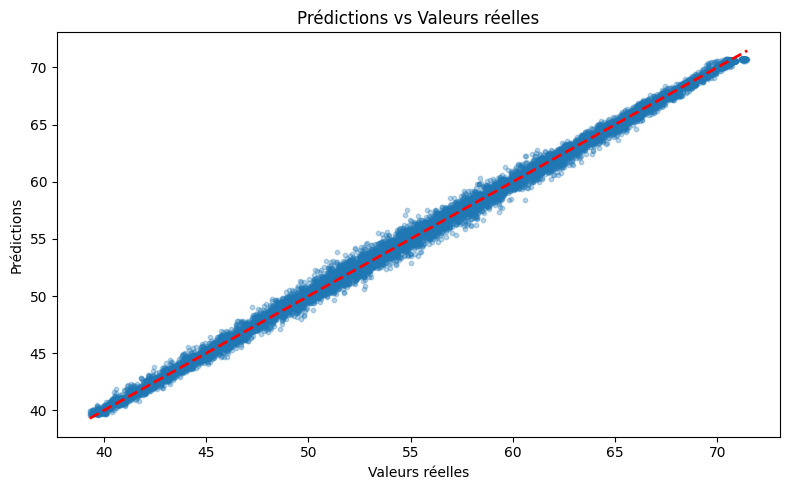

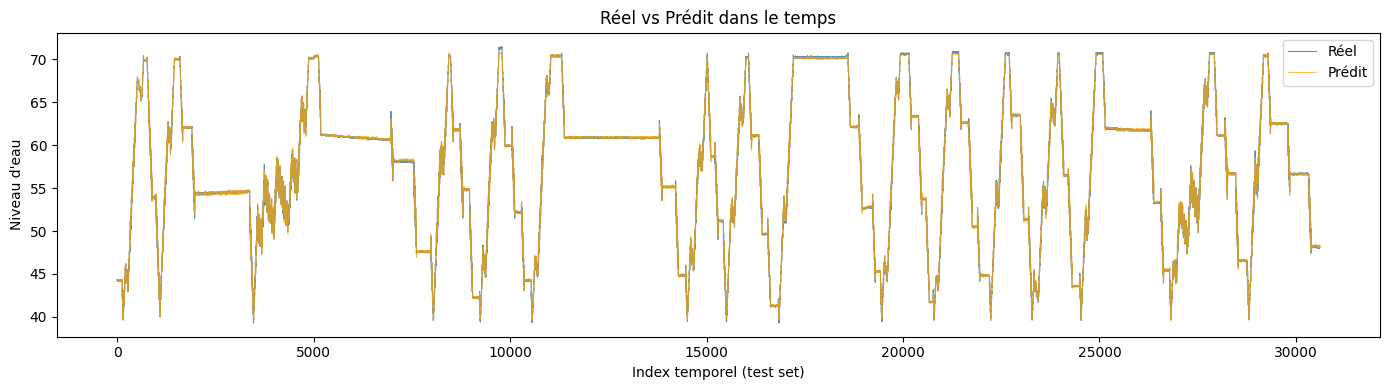

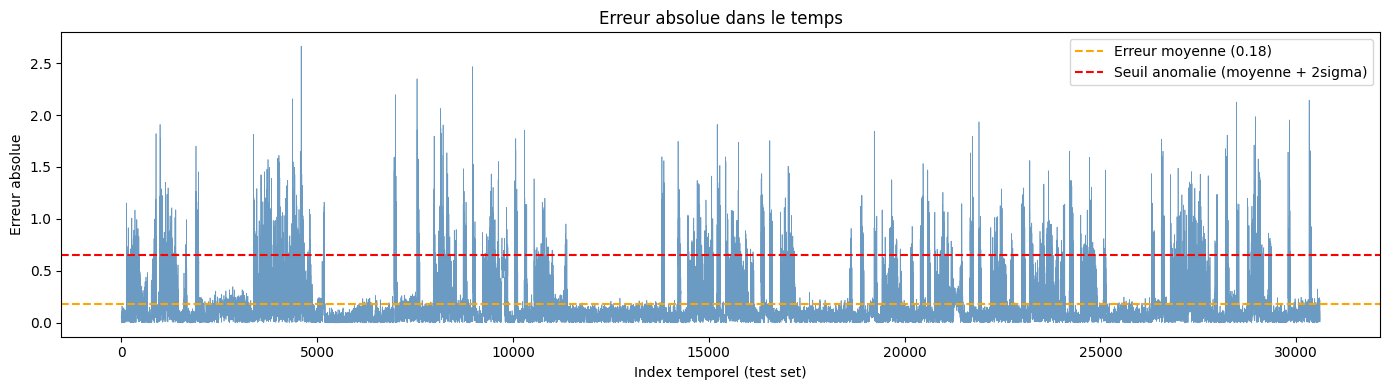


Nombre de pics d'erreur détectés (> moyenne + 3sigma) : 720
Seuil utilisé : 0.8879


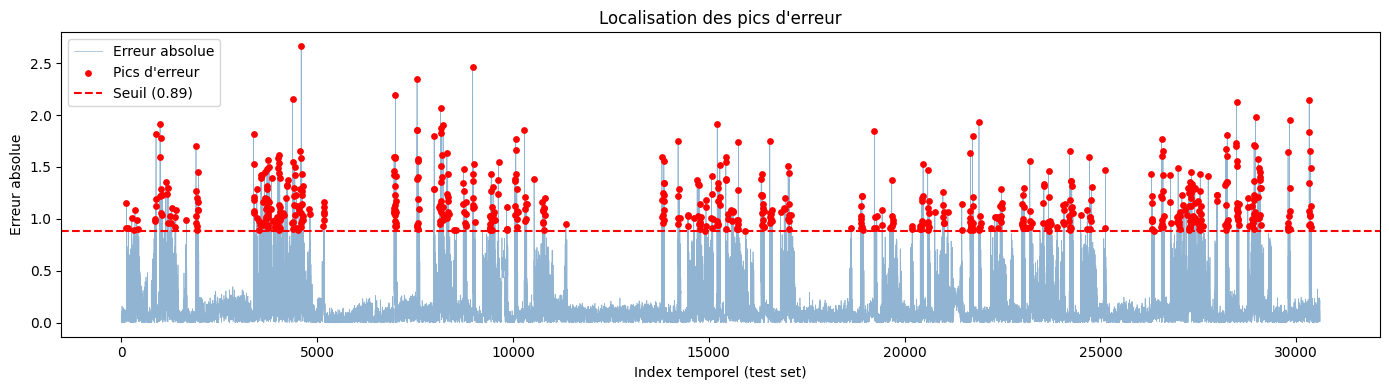

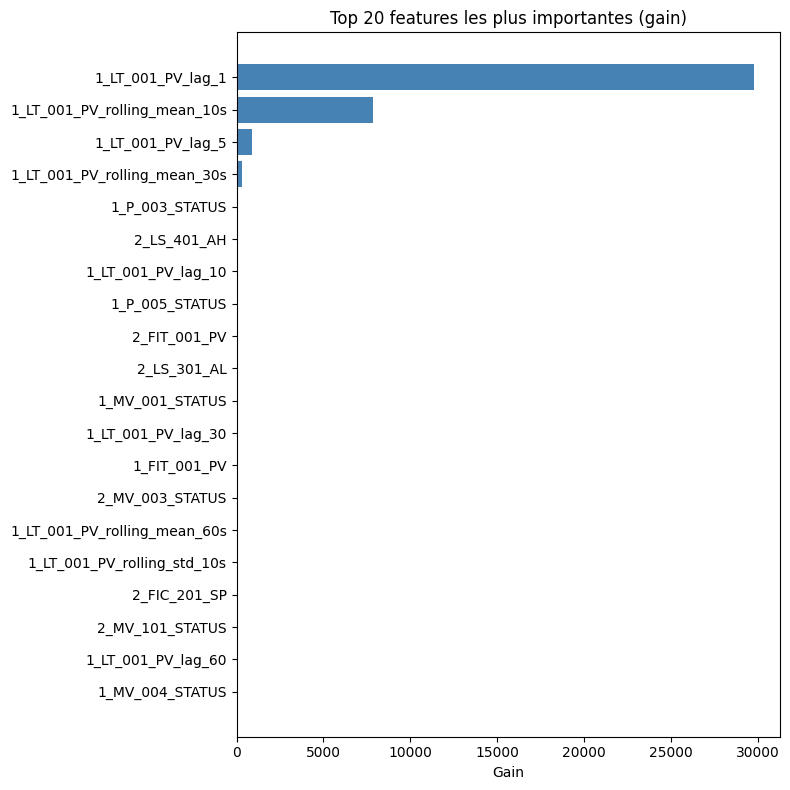


Métriques sauvegardées dans : artefacts/metrics.json


In [15]:
print("Evaluating...")
metrics_result = evaluate_model(model, X_test, y_test)
save_metrics(metrics_result, METRICS_PATH)
print(f"\nMétriques sauvegardées dans : {METRICS_PATH}")

## 7. Conclusion 

- L'approche **régression + résidu** est simple, interprétable et ne nécessite aucun label d'entraînement.
- Le **feature engineering temporel** (lags, rolling stats) permet au modèle de capturer la dynamique du signal.
- **Optuna** trouve de bons hyperparamètres en seulement 15 trials (mais on peut augmenter le nombre de trials si souhaité) .
- L'**early stopping** protège contre l'overfitting sans réglage manuel.
